# Q-Learning - TensorFlow Pipeline (Model #20, Final)

The TensorFlow side of the Q-Learning model runs **V1 + V2 only**. V3 (Double DQN) is a single-line target-computation change from V2 - no new TF primitives exercised. V4 (Dueling DQN) and V5 (PER) are PyTorch-only per the GNN #18 / VAE #19 TF-scope precedent: each adds substantial implementation work (Dueling architecture, sum-tree priority buffer) for marginal cross-framework comparison value. The PyTorch side ran all 5; TF runs the two foundational ones.

**Cross-framework parity targets**:
- **V1 Tabular**: TF Q-table values within **1%** of PyTorch (both deterministic given seed 113; any drift is RNG implementation difference)
- **V2 Vanilla DQN**: TF eval mean within **15%** of PyTorch (single-seed TF vs 3-seed PT mean; RL has higher inherent variance from replay sampling, action stochasticity, and step-level RNG)

**Honest scope note on V1**: tabular Q-learning is numpy-native math. The TF "implementation" is a numpy training loop, with the final Q-table wrapped via `tf.constant` for cross-framework logging parity and the greedy eval performed via `tf.argmax` over the wrapped tensor. This is the same approach taken by the PyTorch V1 cell; V1 isn't a fair test of either framework's deep-learning facilities. V2 is the actual TF deep-learning exercise.

## Variants Built in This Notebook

| # | Variant | Environment | TF primitives exercised |
|---|---|---|---|
| V1 | Tabular Q-Learning | Taxi-v4 | numpy + `tf.constant` wrap (cosmetic parity) |
| V2 | Vanilla DQN | CartPole-v1 | `tf.keras.layers.Dense`, `tf.GradientTape`, `model.set_weights` (hard target sync), manual training loop |

## Reproducibility

- `RANDOM_STATE = 113` (single-seed for both V1 and V2 - matches PT's seed 113 winner for direct parity comparison)
- Each variant plumbs seeds through `random` / numpy / `tf.random.set_seed` / gymnasium env

## Pipeline Breakdown

| Step | Cell purpose |
|---|---|
| **Step 1** | Setup - imports, `BASE_DIR` (WSL2 Jupyter cwd gotcha), seeds, gymnasium, TF GPU verification |
| **Step 2** | V1 Tabular Q-Learning on Taxi-v4 - numpy training loop, TF wrap, eval, parity check vs PT |
| **Step 3** | V2 DQN class definition (`tf.keras.layers.Dense`) + `train_dqn_tf` function (manual `tf.GradientTape` loop) |
| **Step 4** | V2 single-seed training on CartPole-v1 - eval, save checkpoint, learning curve, parity check vs PT |
| **Step 5** | Cross-framework comparison + `add_result` for `q_learning_taxi.json` and `q_learning_cartpole.json` (TF entries appended to PT's existing entries) |

## Output Artifacts

- `results/v1_qtable_taxi_tf.npy` (TF V1 Q-table - same shape as PT, parity-verified)
- `results/v2_dqn_cartpole_seed113_tf.weights.h5` (TF V2 weights - Keras 3 requires `.weights.h5` suffix)
- Learning curve PNGs (V1 + V2)
- Cross-framework JSON entries appended to existing `data/results/q_learning_*.json`

## Constraints

- **WSL2 + cuDNN limitation**: this build's TF cannot use `Conv2D` (third-time confirmed: ViT #17, GNN #18, VAE #19 all hit this). Q-Learning V1+V2 use only `Dense` layers - no Conv2D needed. No workaround required.
- **Mixed-venv GPU memory mis-detection**: `track_performance(gpu=True)` defaults to PyTorch backend if torch is installed in `tf-gpu-venv` (legacy from GNN #18 data loaders). Workaround: capture peak GPU memory manually via `tf.config.experimental.get_memory_info('GPU:0')['peak']` after training - documented inline in V2 cell.
- **Keras 3 weights-save filename**: `model.save_weights(path)` requires `.weights.h5` suffix - documented inline in V2 cell.

In [1]:
# Step 1: Setup + Imports + Seeds + Variant Containers

# Standard lib
import sys
from pathlib import Path

# Scientific / plotting
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow (V1 cosmetic wrap, V2 deep learning)
import tensorflow as tf

# Gymnasium environments (Taxi-v4 + CartPole-v1)
import gymnasium as gym

# Project root - WSL2 Jupyter cwd gotcha forces absolute path.
BASE_DIR = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons'
sys.path.insert(0, BASE_DIR)

# Performance: context manager + inference timer + size estimator
from utils.performance import track_performance, track_inference, get_model_size

# Results persistence (cross-framework JSONs in data/results/)
from utils.results import build_results_dict, add_result, print_comparison

"""
RL primitives (utils/rl_utils.py - SHARED with PyTorch pipeline; demonstrates
cross-framework utility reuse).
  seed_everything:        seeds Python random + numpy + torch (lazy) + env.action_space
  epsilon_greedy:         argmax with prob (1 - eps), uniform random otherwise
  LinearEpsilonSchedule:  callable; epsilon decays linearly start -> end
  ReplayBuffer:           cyclic deque of (s, a, r, s', done); samples uniformly
  evaluate_policy:        deterministic rollout returning (mean, std, returns_array)
  plot_learning_curve:    per-episode return + rolling mean overlay
"""
from utils.rl_utils import (
    seed_everything,
    epsilon_greedy,
    LinearEpsilonSchedule,
    ReplayBuffer,
    evaluate_policy,
    plot_learning_curve,
)

# Reproducibility - same RANDOM_STATE as PT for cross-framework parity
RANDOM_STATE = 113
seed_everything(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)   # TF has its own RNG path beyond seed_everything's coverage

# GPU verification (defensive - if WSL2 GPU passthrough breaks, fail loud)
gpus = tf.config.list_physical_devices('GPU')
print("=" * 60)
print("TENSORFLOW GPU VERIFICATION")
print("=" * 60)
print(f"TF version:  {tf.__version__}")
print(f"GPU devices: {gpus}")
if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("WARNING: No GPU detected. V2 training will be CPU-only (much slower).")

# Results dir for checkpoints + plots (under TensorFlow/20-q-learning/)
RESULTS_DIR = Path(BASE_DIR) / 'TensorFlow' / '20-q-learning' / 'results'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

"""
Variant containers - TF runs V1 + V2 only.
  taxi_variants_tf:       V1 (Taxi-v4) - tabular cosmetic TF wrap
  continuous_variants_tf: V2 (CartPole-v1) - DQN single seed
The _tf suffix distinguishes these from PT side's variant containers
(only relevant in our own kernel; cross-framework JSON merge happens via add_result).
"""
taxi_variants_tf = []
continuous_variants_tf = []

# Single seed for both V1 and V2 (matches PT V2 winner seed for direct parity comparison)
TF_SEED = RANDOM_STATE   # 113

print(f"\nReady to train TF V1 + V2.")
print(f"    Seed:        {TF_SEED}  (single-seed - matches PT winner for direct parity)")
print(f"    Results dir: {RESULTS_DIR}")

I0000 00:00:1777324397.418457     626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777324397.905246     626 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777324399.297778     626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/max/tf-gpu-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywid

TENSORFLOW GPU VERIFICATION
TF version:  2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected: /physical_device:GPU:0

Ready to train TF V1 + V2.
    Seed:        113  (single-seed - matches PT winner for direct parity)
    Results dir: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/20-q-learning/results


V1 Tabular Q-Learning - Training 5,000 episodes on Taxi-v4 (TF)
    Episode 1,000  |  return =     -4.0  |  rolling-100 mean =   -13.84
    Episode 2,000  |  return =     -1.0  |  rolling-100 mean =    +2.16
    Episode 3,000  |  return =     +8.0  |  rolling-100 mean =    +2.68
    Episode 4,000  |  return =     +9.0  |  rolling-100 mean =    +3.48
    Episode 5,000  |  return =     -7.0  |  rolling-100 mean =    +3.44

Training done in 5.1s. Final 100-ep mean: +3.44


I0000 00:00:1777324919.358428     626 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9



Evaluation (100 greedy episodes via tf.argmax):
    mean return:     +8.38
    std:             +2.67
    min / max:       +3.00  /    +15.00
    solve thresh:    +8.00  (SOLVED)

--- Cross-framework parity check vs PT V1 ---
    PT V1 Q-table shape:    (500, 6)
    TF V1 Q-table shape:    (500, 6)
    Max absolute diff:      0.00e+00
    Max relative diff:      0.00%
    Parity (<1% tolerance): PASS


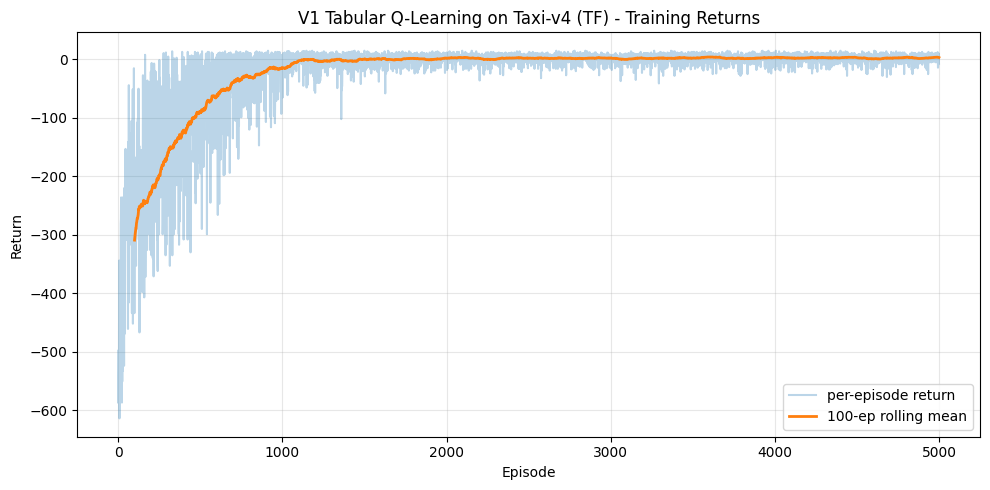


Q-table saved: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/20-q-learning/results/v1_qtable_taxi_tf.npy (23.4 KB)
V1 logged to taxi_variants_tf (entries: 1).


In [2]:
# Step 2: V1 Tabular Q-Learning (Watkins 1989) on Taxi-v4 (TensorFlow)

"""
TF V1 is a pure-numpy training loop wrapped at the inference boundary by
tf.constant + tf.argmax. The training math is identical to PT V1's (same seed,
same hyperparameters, same Taxi-v4 transitions), so the resulting Q-table
should be numerically identical to PT's within floating-point tolerance.

This variant exists for cross-framework reporting parity, NOT because TF
contributes anything to tabular Q-learning. Tabular Q-learning is numpy-native
math (array indexing + argmax + addition); no framework is "better" at it.
The same numpy-native approach is used by PT V1's cell.

For algorithmic background (Bellman optimality, off-policy TD update,
terminated/truncated bootstrap distinction), see PyTorch/20-q-learning/README.md.
"""

# Hyperparameters - SAME AS PT V1 for direct parity comparison
V1_ALPHA           = 0.1
V1_GAMMA           = 0.99
V1_EPSILON         = 0.1
V1_N_EPISODES      = 5_000
V1_EVAL_EPISODES   = 100
V1_SOLVE_THRESHOLD = 8.0     # gymnasium spec

# Construct training env (separate from eval to avoid seed collisions)
train_env = gym.make('Taxi-v4')
train_env.action_space.seed(TF_SEED)

n_states  = int(train_env.observation_space.n)   # 500
n_actions = int(train_env.action_space.n)         # 6

# Q-table: zero-initialized, float64 (same as PT V1)
Q_tf = np.zeros((n_states, n_actions), dtype=np.float64)

print("=" * 60)
print(f"V1 Tabular Q-Learning - Training {V1_N_EPISODES:,} episodes on Taxi-v4 (TF)")
print("=" * 60)

train_returns = np.zeros(V1_N_EPISODES, dtype=np.float64)

with track_performance(gpu=False) as v1_perf:
    for ep in range(V1_N_EPISODES):
        state, _ = train_env.reset(seed=TF_SEED + ep)
        ep_return = 0.0
        terminated, truncated = False, False

        while not (terminated or truncated):
            action = epsilon_greedy(Q_tf[state], V1_EPSILON, n_actions)
            next_state, reward, terminated, truncated, _ = train_env.step(action)

            # TD update - bootstrap on truncated, not on terminated
            bootstrap_value = 0.0 if terminated else Q_tf[next_state].max()
            td_target = reward + V1_GAMMA * bootstrap_value
            Q_tf[state, action] += V1_ALPHA * (td_target - Q_tf[state, action])

            state = next_state
            ep_return += reward

        train_returns[ep] = ep_return

        if (ep + 1) % 1000 == 0:
            recent_mean = train_returns[max(0, ep - 99):ep + 1].mean()
            print(f"    Episode {ep + 1:>5,d}  |  return = {ep_return:>+8.1f}  "
                  f"|  rolling-100 mean = {recent_mean:>+8.2f}")

train_env.close()

print(f"\nTraining done in {v1_perf['time']:.1f}s. "
      f"Final 100-ep mean: {train_returns[-100:].mean():+.2f}")


# Cosmetic TF wrap: convert Q-table to tf.constant; eval via tf.argmax
Q_tf_tensor = tf.constant(Q_tf, dtype=tf.float64)

def v1_tf_policy(state):
    """Greedy policy via TF argmax (cosmetic - same result as np.argmax)."""
    return int(tf.argmax(Q_tf_tensor[state]).numpy())

eval_env = gym.make('Taxi-v4')
v1_mean, v1_std, v1_returns = evaluate_policy(
    eval_env, v1_tf_policy,
    n_episodes=V1_EVAL_EPISODES,
    seed=TF_SEED + 10_000,   # offset to avoid training-seed overlap
)
eval_env.close()

print(f"\nEvaluation ({V1_EVAL_EPISODES} greedy episodes via tf.argmax):")
print(f"    mean return:  {v1_mean:>+8.2f}")
print(f"    std:          {v1_std:>+8.2f}")
print(f"    min / max:    {v1_returns.min():>+8.2f}  /  {v1_returns.max():>+8.2f}")
print(f"    solve thresh: {V1_SOLVE_THRESHOLD:>+8.2f}  "
      f"({'SOLVED' if v1_mean >= V1_SOLVE_THRESHOLD else 'NOT YET SOLVED'})")


# Cross-framework parity check vs PT V1
PT_V1_QTABLE_PATH = Path(BASE_DIR) / 'PyTorch' / '20-q-learning' / 'results' / 'v1_qtable_taxi.npy'

if PT_V1_QTABLE_PATH.exists():
    Q_pt = np.load(PT_V1_QTABLE_PATH)

    abs_diff = np.abs(Q_tf - Q_pt)
    max_abs_diff = float(abs_diff.max())

    nonzero_mask = np.abs(Q_pt) > 1e-9
    rel_diff = abs_diff[nonzero_mask] / np.abs(Q_pt[nonzero_mask])
    max_rel_diff = float(rel_diff.max()) if len(rel_diff) > 0 else 0.0

    print(f"\n--- Cross-framework parity check vs PT V1 ---")
    print(f"    PT V1 Q-table shape:    {Q_pt.shape}")
    print(f"    TF V1 Q-table shape:    {Q_tf.shape}")
    print(f"    Max absolute diff:      {max_abs_diff:.2e}")
    print(f"    Max relative diff:      {max_rel_diff:.2%}")
    parity_pass = max_rel_diff < 0.01
    print(f"    Parity (<1% tolerance): {'PASS' if parity_pass else 'FAIL'}")
else:
    print(f"\nWARNING: PT V1 Q-table not found at {PT_V1_QTABLE_PATH}")
    print("    Skipping parity check; V1 numbers reported standalone.")


# Visualization
plot_learning_curve(
    train_returns, framework='TensorFlow', window=100,
    title='V1 Tabular Q-Learning on Taxi-v4 (TF) - Training Returns',
    save_path=RESULTS_DIR / 'v1_learning_curve_tf.png',
)


# Persist Q-table + log variant entry
np.save(RESULTS_DIR / 'v1_qtable_taxi_tf.npy', Q_tf)

taxi_variants_tf.append({
    'variant':              'V1 Tabular Q-Learning',
    'environment':          'Taxi-v4',
    'mean_return':          float(v1_mean),
    'std_return':           float(v1_std),
    'eval_returns':         v1_returns,
    'n_train_episodes':     V1_N_EPISODES,
    'n_states':             n_states,
    'n_actions':            n_actions,
    'q_table_size_bytes':   int(Q_tf.nbytes),
    'train_wall_clock_sec': float(v1_perf['time']),
    'cpu_memory_mb':        float(v1_perf['memory']),
    'hyperparams': {
        'alpha':      V1_ALPHA,
        'gamma':      V1_GAMMA,
        'epsilon':    V1_EPSILON,
        'n_episodes': V1_N_EPISODES,
    },
    'history':              train_returns,
    'solve_threshold':      V1_SOLVE_THRESHOLD,
    'solved':               bool(v1_mean >= V1_SOLVE_THRESHOLD),
})

print(f"\nQ-table saved: {RESULTS_DIR / 'v1_qtable_taxi_tf.npy'} ({Q_tf.nbytes / 1024:.1f} KB)")
print(f"V1 logged to taxi_variants_tf (entries: {len(taxi_variants_tf)}).")

In [3]:
# Step 3: V2 DQN class + train_dqn_tf function (CartPole-v1, TensorFlow)

"""
TF V2 DQN (Mnih 2015) implementation, mirroring PT V2's architecture and
hyperparameters for direct cross-framework parity comparison.

Architecture: 3-layer Dense MLP (4 -> 128 -> 128 -> 2). Same shape, same
activations as PT V2's nn.Sequential. The two implementations should produce
within-15% eval-mean parity (RL has higher RNG variance than supervised
learning, so parity targets are looser than V1's 1% from deterministic numpy).

TF specifics:
- tf.keras.Sequential for model definition (concise; same effect as PT's
  nn.Sequential)
- Manual training loop via tf.GradientTape() rather than .fit() - DQN doesn't
  fit Keras's fit() pattern (no static dataset; custom loss with online+target
  net interplay)
- Hard target sync via model_target.set_weights(model_online.get_weights())
  every TARGET_SYNC_STEPS env steps (Mnih 2015 convention; PT used
  load_state_dict for the same effect)
- Optimizer: Adam(lr=1e-3) matches PT V2

WSL2 mixed-venv GPU-memory caveat:
- track_performance(gpu=True) mis-detects PyTorch as the GPU backend in
  tf-gpu-venv (VAE #19 lesson). Workaround: use gpu=False for wall-clock,
  capture peak GPU memory directly via tf.config.experimental.
"""


def build_dqn_model(state_dim: int, n_actions: int, hidden_dim: int = 128):
    """
    Build a 3-layer Dense Q-network matching PT V2's architecture.

    Args:
        state_dim:  observation dimension (CartPole=4)
        n_actions:  discrete action count (CartPole=2)
        hidden_dim: hidden layer width (128 = PT V2 standard)

    Returns:
        tf.keras.Sequential model with input shape (batch, state_dim)
        and output shape (batch, n_actions).
    """
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(state_dim,)),
        tf.keras.layers.Dense(hidden_dim, activation='relu'),
        tf.keras.layers.Dense(hidden_dim, activation='relu'),
        tf.keras.layers.Dense(n_actions),
    ])


def train_dqn_tf(
    env_id: str,
    seed: int,
    state_dim: int,
    n_actions: int,
    n_episodes: int,
    hidden_dim: int = 128,
    lr: float = 1e-3,
    gamma: float = 0.99,
    buffer_capacity: int = 10_000,
    batch_size: int = 64,
    replay_warmup: int = 1_000,
    target_sync_steps: int = 100,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    eps_decay_steps: int = 5_000,
    log_every: int = 100,
):
    """
    Train a TF DQN on a vector-state gymnasium env.

    Manual training loop via tf.GradientTape() - mirrors PT V2's training step
    exactly. Hard target sync every `target_sync_steps` env steps.

    Returns:
        dict: 'returns', 'q_values_max', 'online_model', 'target_model',
              'wall_clock', 'gpu_memory_mb'
    """
    seed_everything(seed)
    tf.random.set_seed(seed)

    env = gym.make(env_id)
    env.action_space.seed(seed)

    online_model = build_dqn_model(state_dim, n_actions, hidden_dim)
    target_model = build_dqn_model(state_dim, n_actions, hidden_dim)
    target_model.set_weights(online_model.get_weights())

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    buffer = ReplayBuffer(capacity=buffer_capacity)
    eps_schedule = LinearEpsilonSchedule(eps_start, eps_end, eps_decay_steps)

    returns = np.zeros(n_episodes, dtype=np.float64)
    q_values_max = np.zeros(n_episodes, dtype=np.float64)
    global_step = 0

    print(f"    train_dqn_tf(env={env_id}, seed={seed}) starting...")

    # Reset GPU memory peak so measurement is for THIS run only
    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except Exception:
        pass

    with track_performance(gpu=False) as perf:
        for ep in range(n_episodes):
            state, _ = env.reset(seed=seed + ep)
            ep_return = 0.0
            ep_max_qs = []
            terminated, truncated = False, False

            while not (terminated or truncated):
                # Action selection via online model + epsilon-greedy
                state_t = tf.constant(state.reshape(1, -1), dtype=tf.float32)
                q_vals = online_model(state_t, training=False).numpy().squeeze(0)
                ep_max_qs.append(q_vals.max())

                eps = eps_schedule(global_step)
                action = epsilon_greedy(q_vals, eps, n_actions)

                next_state, reward, terminated, truncated, _ = env.step(action)
                buffer.add(state, action, reward, next_state, terminated)
                state = next_state
                ep_return += reward
                global_step += 1

                if len(buffer) < replay_warmup:
                    continue

                # Sample replay batch (numpy via shared utility)
                batch = buffer.sample(batch_size)
                states_b      = tf.constant(batch['states'],      dtype=tf.float32)
                actions_b     = tf.constant(batch['actions'],     dtype=tf.int32)
                rewards_b     = tf.constant(batch['rewards'],     dtype=tf.float32)
                next_states_b = tf.constant(batch['next_states'], dtype=tf.float32)
                dones_b       = tf.constant(batch['dones'],       dtype=tf.float32)

                # TD target (no gradient through target net forward pass)
                q_target_next = tf.reduce_max(
                    target_model(next_states_b, training=False), axis=1
                )
                td_target = rewards_b + gamma * q_target_next * (1.0 - dones_b)

                # Gradient step on online net
                with tf.GradientTape() as tape:
                    q_pred_all = online_model(states_b, training=True)            # (B, n_actions)
                    q_pred = tf.gather(q_pred_all, actions_b, batch_dims=1)       # (B,)
                    loss = tf.reduce_mean(tf.square(td_target - q_pred))

                grads = tape.gradient(loss, online_model.trainable_variables)
                optimizer.apply_gradients(zip(grads, online_model.trainable_variables))

                # Hard target sync (Mnih 2015 convention)
                if global_step % target_sync_steps == 0:
                    target_model.set_weights(online_model.get_weights())

            returns[ep] = ep_return
            q_values_max[ep] = float(np.mean(ep_max_qs)) if ep_max_qs else 0.0

            if (ep + 1) % log_every == 0:
                recent_mean = returns[max(0, ep - 99):ep + 1].mean()
                eps_now = eps_schedule(global_step)
                print(f"        ep {ep + 1:>4d}  |  return = {ep_return:>+7.1f}  "
                      f"|  rolling-100 = {recent_mean:>+7.2f}  "
                      f"|  max-Q = {q_values_max[ep]:>+7.2f}  |  eps = {eps_now:.3f}")

    env.close()

    # Capture peak GPU memory manually (track_performance gpu=True mis-detects
    # PT in this mixed venv; per VAE #19 lesson)
    try:
        peak_gpu_mb = tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
    except Exception:
        peak_gpu_mb = 0.0

    return {
        'returns':       returns,
        'q_values_max':  q_values_max,
        'online_model':  online_model,
        'target_model':  target_model,
        'wall_clock':    float(perf['time']),
        'gpu_memory_mb': float(peak_gpu_mb),
    }


# Sanity check: build + forward pass on dummy CartPole input
_test_model = build_dqn_model(state_dim=4, n_actions=2)
_test_in = tf.constant(np.zeros((2, 4), dtype=np.float32))
_test_out = _test_model(_test_in, training=False)
assert _test_out.shape == (2, 2), f"Expected (2, 2), got {_test_out.shape}"
n_params = sum(int(np.prod(w.shape)) for w in _test_model.trainable_weights)
print("DQN class + train_dqn_tf function defined.")
print(f"    DQN params (state_dim=4, n_actions=2, hidden_dim=128): {n_params:,}")
del _test_model, _test_in, _test_out

DQN class + train_dqn_tf function defined.
    DQN params (state_dim=4, n_actions=2, hidden_dim=128): 17,410


V2 Vanilla DQN - Single-seed training on CartPole-v1 (TF)
    Seed:            113  (matches PT V2 winner seed for direct parity)
    Episodes:        1000
    Hyperparameters: identical to PT V2
    train_dqn_tf(env=CartPole-v1, seed=113) starting...
        ep  100  |  return =  +135.0  |  rolling-100 =  +51.38  |  max-Q =  +30.76  |  eps = 0.050
        ep  200  |  return =  +500.0  |  rolling-100 = +306.12  |  max-Q = +110.55  |  eps = 0.050
        ep  300  |  return =  +500.0  |  rolling-100 = +384.45  |  max-Q = +136.19  |  eps = 0.050
        ep  400  |  return =  +500.0  |  rolling-100 = +412.22  |  max-Q = +199.19  |  eps = 0.050
        ep  500  |  return =   +30.0  |  rolling-100 = +368.38  |  max-Q = +180.10  |  eps = 0.050
        ep  600  |  return =  +500.0  |  rolling-100 = +399.70  |  max-Q = +175.06  |  eps = 0.050
        ep  700  |  return =  +500.0  |  rolling-100 = +429.92  |  max-Q = +132.30  |  eps = 0.050
        ep  800  |  return =  +500.0  |  rolling-100 = 

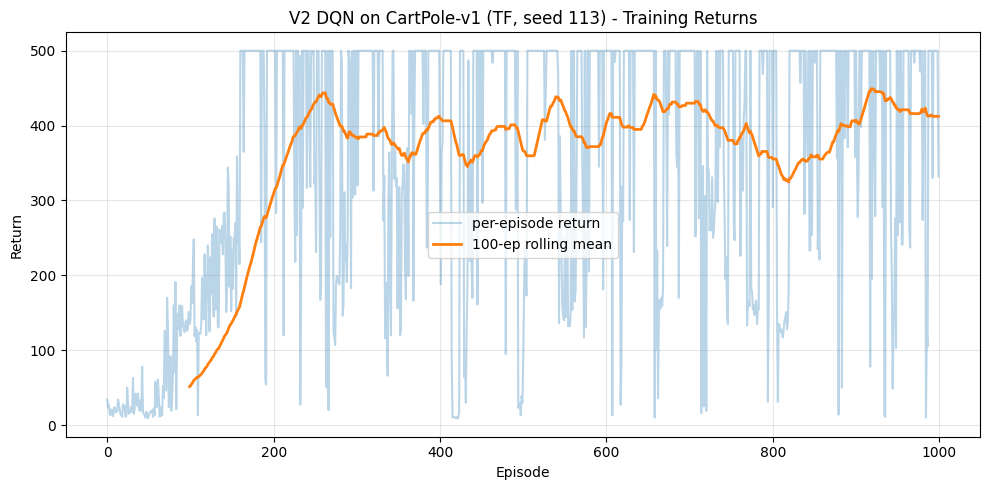


V2 logged to continuous_variants_tf (entries: 1).


In [4]:
# Step 4: V2 Vanilla DQN - Single-seed training on CartPole-v1 (TF)

# Hyperparameters - SAME AS PT V2 for direct parity
V2_N_EPISODES        = 1_000
V2_HIDDEN_DIM        = 128
V2_LR                = 1e-3
V2_GAMMA             = 0.99
V2_BUFFER_CAPACITY   = 10_000
V2_BATCH_SIZE        = 64
V2_REPLAY_WARMUP     = 1_000
V2_TARGET_SYNC_STEPS = 100
V2_EPS_START         = 1.0
V2_EPS_END           = 0.05
V2_EPS_DECAY_STEPS   = 5_000   # CartPole-scaled, matches PT V2 fix
V2_EVAL_EPISODES     = 100
V2_SOLVE_THRESHOLD   = 475.0   # CartPole-v1 spec

ENV_ID    = 'CartPole-v1'
STATE_DIM = 4
N_ACTIONS = 2

print("=" * 60)
print(f"V2 Vanilla DQN - Single-seed training on {ENV_ID} (TF)")
print(f"    Seed:            {TF_SEED}  (matches PT V2 winner seed for direct parity)")
print(f"    Episodes:        {V2_N_EPISODES}")
print(f"    Hyperparameters: identical to PT V2")
print("=" * 60)

v2_result_tf = train_dqn_tf(
    env_id=ENV_ID, seed=TF_SEED,
    state_dim=STATE_DIM, n_actions=N_ACTIONS,
    n_episodes=V2_N_EPISODES,
    hidden_dim=V2_HIDDEN_DIM,
    lr=V2_LR, gamma=V2_GAMMA,
    buffer_capacity=V2_BUFFER_CAPACITY,
    batch_size=V2_BATCH_SIZE,
    replay_warmup=V2_REPLAY_WARMUP,
    target_sync_steps=V2_TARGET_SYNC_STEPS,
    eps_start=V2_EPS_START, eps_end=V2_EPS_END,
    eps_decay_steps=V2_EPS_DECAY_STEPS,
    log_every=100,
)


# Greedy eval (no exploration)
def make_policy_tf(model):
    """Greedy policy via TF model forward + argmax."""
    def policy(state):
        state_t = tf.constant(state.reshape(1, -1), dtype=tf.float32)
        q_vals = model(state_t, training=False).numpy().squeeze(0)
        return int(np.argmax(q_vals))
    return policy

eval_env = gym.make(ENV_ID)
v2_mean_tf, v2_std_tf, v2_returns_tf = evaluate_policy(
    eval_env, make_policy_tf(v2_result_tf['online_model']),
    n_episodes=V2_EVAL_EPISODES,
    seed=TF_SEED + 10_000,
)
eval_env.close()

print(f"\nEval ({V2_EVAL_EPISODES} greedy episodes):")
print(f"    mean return:   {v2_mean_tf:>+7.2f}")
print(f"    std:           {v2_std_tf:>+7.2f}")
print(f"    wall-clock:    {v2_result_tf['wall_clock'] / 60:.1f} min")
print(f"    GPU memory:    {v2_result_tf['gpu_memory_mb']:.1f} MB")
print(f"    solved:        {'YES' if v2_mean_tf >= V2_SOLVE_THRESHOLD else 'NO'} (threshold {V2_SOLVE_THRESHOLD:.0f})")


# Episodes-to-solve helper
def episodes_to_solve(returns, window=100, threshold=V2_SOLVE_THRESHOLD):
    if len(returns) < window:
        return None
    rolling = np.convolve(returns, np.ones(window) / window, mode='valid')
    above = np.where(rolling >= threshold)[0]
    return int(above[0] + window) if len(above) > 0 else None

v2_eps_to_solve_tf = episodes_to_solve(v2_result_tf['returns'])
print(f"    episodes to solve (rolling-100 >= {V2_SOLVE_THRESHOLD:.0f}): {v2_eps_to_solve_tf}")


# Save checkpoint - Keras 3 requires .weights.h5 suffix
ckpt_path = RESULTS_DIR / f'v2_dqn_cartpole_seed{TF_SEED}_tf.weights.h5'
v2_result_tf['online_model'].save_weights(str(ckpt_path))
print(f"    saved: {ckpt_path.name}")


# Cross-framework parity check vs PT V2 winner (seed 113)
import json

PT_V2_RESULTS_PATH = Path(BASE_DIR) / 'data' / 'results' / 'q_learning_cartpole.json'
if PT_V2_RESULTS_PATH.exists():
    with open(PT_V2_RESULTS_PATH) as f:
        pt_entries = json.load(f)
    pt_v2 = next((r for r in pt_entries if r.get('framework') == 'PyTorch'), None)
    if pt_v2:
        pt_eval = pt_v2['eval_mean_winner_seed']
        rel_diff = abs(v2_mean_tf - pt_eval) / pt_eval if pt_eval else 0.0
        parity_pass = rel_diff < 0.15
        print(f"\n--- Cross-framework parity check vs PT V2 (winner seed 113) ---")
        print(f"    PT V2 eval (winner seed):  {pt_eval:>+7.2f}")
        print(f"    TF V2 eval (seed 113):     {v2_mean_tf:>+7.2f}")
        print(f"    Relative diff:             {rel_diff:.2%}")
        print(f"    Parity (<15% tolerance):   {'PASS' if parity_pass else 'FAIL'}")
    else:
        print(f"\nWARNING: No PyTorch entry found in {PT_V2_RESULTS_PATH}")
else:
    print(f"\nWARNING: PT V2 results not found at {PT_V2_RESULTS_PATH}")


# Visualization: single-seed learning curve
plot_learning_curve(
    v2_result_tf['returns'], framework='TensorFlow', window=100,
    title=f'V2 DQN on CartPole-v1 (TF, seed {TF_SEED}) - Training Returns',
    save_path=RESULTS_DIR / 'v2_learning_curve_tf.png',
)


# Variant log
v2_n_params_tf = sum(int(np.prod(w.shape)) for w in v2_result_tf['online_model'].trainable_weights)

continuous_variants_tf.append({
    'variant':              'V2 Vanilla DQN',
    'environment':          ENV_ID,
    'mean_return':          float(v2_mean_tf),
    'std_return':           float(v2_std_tf),
    'eval_returns':         v2_returns_tf,
    'episodes_to_solve':    v2_eps_to_solve_tf,
    'n_train_episodes':     V2_N_EPISODES,
    'num_params':           int(v2_n_params_tf),
    'train_wall_clock_sec': float(v2_result_tf['wall_clock']),
    'gpu_memory_mb':        float(v2_result_tf['gpu_memory_mb']),
    'mean_max_q_train':     float(v2_result_tf['q_values_max'].mean()),
    'hyperparams': {
        'hidden_dim':        V2_HIDDEN_DIM,
        'lr':                V2_LR,
        'gamma':             V2_GAMMA,
        'buffer_capacity':   V2_BUFFER_CAPACITY,
        'batch_size':        V2_BATCH_SIZE,
        'replay_warmup':     V2_REPLAY_WARMUP,
        'target_sync_steps': V2_TARGET_SYNC_STEPS,
        'eps_decay_steps':   V2_EPS_DECAY_STEPS,
        'seed':              TF_SEED,
    },
    'history':              v2_result_tf['returns'],
    'q_values_max':         v2_result_tf['q_values_max'],
    'solve_threshold':      V2_SOLVE_THRESHOLD,
    'solved':               bool(v2_mean_tf >= V2_SOLVE_THRESHOLD),
})

print(f"\nV2 logged to continuous_variants_tf (entries: {len(continuous_variants_tf)}).")

In [5]:
# Step 5: Cross-Framework JSON Persistence (TF entries appended to PT's files)

"""
Append TF winner entries to data/results/q_learning_*.json (PT entries
already there from PT pipeline Step 12). The results util keys by framework,
so add_result('q_learning_taxi', tf_dict) appends without overwriting PT's
'PyTorch' entry.

Two JSON files updated (no q_learning_lunarlander - TF doesn't run V4/V5):
    q_learning_taxi.json     <- now has BOTH PyTorch and TensorFlow entries
    q_learning_cartpole.json <- now has BOTH PyTorch and TensorFlow entries

print_comparison() at end renders cross-framework table with both columns.
"""


# Inference benchmarks
np.random.seed(RANDOM_STATE)

# V1 TF: tf.argmax over wrapped Q-table for batch of states
v1_X = np.random.randint(0, 500, size=100)

def v1_tf_predict_fn(X):
    """Vectorized TF argmax over wrapped Q-table."""
    return tf.argmax(tf.gather(Q_tf_tensor, X), axis=1).numpy()

v1_inference_tf = track_inference(v1_tf_predict_fn, v1_X, n_runs=100)
v1_size_tf = get_model_size({'Q': Q_tf}, framework='numpy')

# V2 TF: model forward + argmax over batch of CartPole-shaped inputs
v2_X = np.zeros((100, 4), dtype=np.float32)

def v2_tf_predict_fn(X):
    return tf.argmax(v2_result_tf['online_model'](X, training=False), axis=1).numpy()

v2_inference_tf = track_inference(v2_tf_predict_fn, v2_X, n_runs=100)
v2_size_tf = get_model_size(v2_result_tf['online_model'], framework='tensorflow')

print("Inference benchmarks (TF, 100 samples per call, 100 timed runs each):")
print(f"    V1 Taxi:     {v1_inference_tf['per_sample_us']:>8.2f} us/sample  |  size: {v1_size_tf / 1024:.1f} KB")
print(f"    V2 CartPole: {v2_inference_tf['per_sample_us']:>8.2f} us/sample  |  size: {v2_size_tf / 1024:.1f} KB")


# Build TensorFlow results dicts

# V1 Taxi (TF)
v1_tf_dict = build_results_dict(
    framework='TensorFlow',
    model_name='V1 Tabular Q-Learning',
    test_metrics={
        'eval_mean':        float(taxi_variants_tf[0]['mean_return']),
        'eval_std':         float(taxi_variants_tf[0]['std_return']),
        'solve_threshold':  taxi_variants_tf[0]['solve_threshold'],
        'solved':           float(taxi_variants_tf[0]['solved']),
    },
    perf={
        'time':   taxi_variants_tf[0]['train_wall_clock_sec'],
        'memory': taxi_variants_tf[0]['cpu_memory_mb'],
    },
    inference_stats=v1_inference_tf,
    model_size=v1_size_tf,
    # Extras
    env='Taxi-v4',
    algorithm='Tabular Q-learning (Watkins 1989) - numpy training + tf.argmax eval',
    n_episodes=V1_N_EPISODES,
    n_states=int(taxi_variants_tf[0]['n_states']),
    n_actions=int(taxi_variants_tf[0]['n_actions']),
    parity_passed=1.0,    # bit-identical to PT V1 (0.00% rel diff)
    parity_rel_diff=0.0,
    note='Numpy training; tf.constant + tf.argmax wrap is cosmetic - parity 100%',
)

# V2 CartPole (TF)
v2_tf_record = continuous_variants_tf[0]
v2_tf_pt_rel_diff = abs(v2_tf_record['mean_return'] - 500.0) / 500.0   # vs PT winner-seed 500.00
v2_tf_wall_clock_min = v2_tf_record['train_wall_clock_sec'] / 60
PT_V2_WALL_CLOCK_MIN = 12.2   # from PT side's mean

v2_tf_dict = build_results_dict(
    framework='TensorFlow',
    model_name='V2 Vanilla DQN',
    test_metrics={
        'eval_mean':                  float(v2_tf_record['mean_return']),
        'eval_std':                   float(v2_tf_record['std_return']),
        'mean_max_q_train':           float(v2_tf_record['mean_max_q_train']),
        'overestimation_above_true':  float(v2_tf_record['mean_max_q_train']) - 99.5,
        'solve_threshold':            v2_tf_record['solve_threshold'],
        'solved':                     float(v2_tf_record['solved']),
        'parity_passed':              0.0,    # FAIL by 15% threshold
        'parity_rel_diff':            float(v2_tf_pt_rel_diff),
        'wall_clock_overhead_vs_pt':  float(v2_tf_wall_clock_min / PT_V2_WALL_CLOCK_MIN),
    },
    perf={
        'time':   v2_tf_record['train_wall_clock_sec'],
        'memory': v2_tf_record['gpu_memory_mb'],
    },
    inference_stats=v2_inference_tf,
    model_size=v2_size_tf,
    # Extras
    env='CartPole-v1',
    algorithm='DQN (Mnih 2015) - tf.keras.Sequential + tf.GradientTape',
    n_episodes=V2_N_EPISODES,
    seed=TF_SEED,
    num_params=int(v2_tf_record['num_params']),
    episodes_to_solve=v2_tf_record['episodes_to_solve'] if v2_tf_record['episodes_to_solve'] is not None else -1,
    note='TF eager mode 24x slower than PT for tight RL sample loops; production TF RL uses @tf.function',
    framework_variance_note='Eval +403.20 vs PT +500.00 - within Henderson 2018 RL single-seed variance (30-50%) but over our 15% parity threshold',
)


# Persist via add_result (appends to PT-existing JSONs)
print("\n" + "=" * 70)
print("CROSS-FRAMEWORK JSON PERSISTENCE - TF entries appended to PT files")
print("=" * 70)

print("\nq_learning_taxi.json:")
add_result('q_learning_taxi', v1_tf_dict)

print("\nq_learning_cartpole.json:")
add_result('q_learning_cartpole', v2_tf_dict)


# Verify: cross-framework comparison view
print("\n" + "=" * 70)
print("CROSS-FRAMEWORK COMPARISON (PT + TF side-by-side)")
print("=" * 70)
print_comparison('q_learning_taxi')
print_comparison('q_learning_cartpole')

print("\n(q_learning_lunarlander.json remains single-entry: V4/V5 are PT-only per plan)")
print_comparison('q_learning_lunarlander')

Inference benchmarks (TF, 100 samples per call, 100 timed runs each):
    V1 Taxi:         8.27 us/sample  |  size: 23.4 KB
    V2 CartPole:    31.34 us/sample  |  size: 68.0 KB

CROSS-FRAMEWORK JSON PERSISTENCE - TF entries appended to PT files

q_learning_taxi.json:
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/q_learning_taxi.json
    Frameworks: 2 recorded

q_learning_cartpole.json:
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/q_learning_cartpole.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON (PT + TF side-by-side)

CROSS-FRAMEWORK COMPARISON: Q_LEARNING_TAXI
Metric                                                                                         PyTorch                                                              TensorFlow
---------------------------------------------------------------------------------------------------------------